In [20]:
import operator
import random
from typing import Annotated, List, TypedDict, Dict, Literal
from langgraph.graph import StateGraph, END, START
from langgraph.types import Send
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.infrastructure.mongo.service import MongoService
from dotenv import load_dotenv
import os
import boto3
from langchain_aws import ChatBedrockConverse
from pydantic import BaseModel, Field
from langchain_aws import ChatBedrockConverse
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
import pandas as pd
import re
import logging
from IPython.display import Image, display
import json
from IPython.display import Image, display
from src.infrastructure.neo4j.service import Neo4jConnector

In [21]:
#load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_ROOT / '.env')
AWS_ACCESS_KEY_ID =os.environ['AWS_ACCESS_KEY_ID']
AWS_SECRET_ACCESS_KEY = os.environ['AWS_SECRET_ACCESS_KEY']
LANGSMITH_API_KEY = os.environ['LANGSMITH_API_KEY']

# --- CONFIGURATION ---
# Using Amazon Nova Lite for speed and cost efficiency
llm = ChatBedrockConverse(
    model="us.amazon.nova-2-lite-v1:0",
    temperature=0
)

# Initialize the connector globally or pass it in via the LangGraph config
neo4j_db = Neo4jConnector()


Successfully connected to Neo4j.


In [22]:
# --- 1. Configure Logging ---
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - [%(funcName)s] - %(message)s'
)
logger = logging.getLogger(__name__)

def merge_taxonomy_trees(left: dict, right: dict) -> dict:
    """
    Reducer function to safely merge parallel dictionary updates.
    Combines the existing taxonomy tree with the newly generated branches.
    """
    # If either side is missing, default to an empty dict
    if not left: left = {}
    if not right: right = {}
    
    merged = left.copy()
    merged.update(right)
    return merged

# --- 2. Define the Typed States ---
class PipelineState(TypedDict):
    mongo_query: Dict 
    mongo_projection: Dict 
    raw_threads: List[dict] 
    normalized_summaries: Annotated[List[dict], operator.add] 
    failed_threads: Annotated[List[str], operator.add]
    
    # --- NEW STATES ---
    anchored_threads: Annotated[List[dict], operator.add] 
    # --- THE FIX ---
    # LangGraph will now automatically route concurrent updates through your merge function
    taxonomy_tree: Annotated[Dict, merge_taxonomy_trees]
    
    # NEW: Store the extracted graphs
    extracted_graphs: Annotated[List[dict], operator.add]

class ThreadWorkerState(TypedDict):
    thread_id: str
    transcript: str
    
class RouterWorkerState(TypedDict):
    thread_id: str
    summary: str
    topic: str  # Add this line
    
class TnTWorkerState(TypedDict):
    root_id: str
    summaries: List[str]
    current_tree: Dict
    
class NormalizedThreadOutput(BaseModel):
    """Schema for the Dialogue-to-Description transformation."""
    summary: str = Field(
        description="The fluent, cohesive third-person descriptive narrative of the thread. Must have resolved pronouns and be in formal English."
    )
    
class Triplet(BaseModel):
    subject: str = Field(
        description="The acting entity. MUST be a concise, canonical noun in Title Case (e.g., 'United States', 'Dr. Aimé Bonny'). NO underscores or full sentences."
    )
    predicate: str = Field(
        description="The action or relationship, formatted strictly in snake_case (e.g., 'accused_of_criticizing', 'allies_with')."
    )
    object: str = Field(
        description="The receiving entity or concept. MUST be a concise, canonical noun in Title Case (e.g., 'Medical Education Standards'). NO underscores or full sentences."
    )
    context: str = Field(
        description="The detailed claim, quote, or narrative explaining exactly why this relationship exists in the text. Capture all nuance here."
    )
class GraphExtraction(BaseModel):
    triplets: List[Triplet] = Field(description="List of structured S-P-O relationships with their contextual evidence.")

In [23]:
class L3Topic(BaseModel):
    """A granular, specific topic derived from the thread."""
    name: str = Field(description="The concise name of the topic (2-4 words maximum).")
    
class L2Domain(BaseModel):
    """A broad categorization domain."""
    name: str = Field(description="The name of the L2 domain (2-4 words).")
    topics: List[L3Topic] = Field(description="A flat list of L3 topics that belong to this domain. Do not nest further.")

class TaxonomyUpdate(BaseModel):
    """The complete updated taxonomy for a specific Root."""
    domains: List[L2Domain] = Field(description="List of L2 domains and their respective L3 topics.")

In [24]:
PREPROCESSOR_SYSTEM_PROMPT = """
<system_prompt>
  <role_and_objective>
    You are an expert Geopolitical Intelligence Analyst. Your objective is to transform raw, multi-turn chat transcripts into concise, thematic intelligence briefs.
  </role_and_objective>
  
  <execution_rules>
    <rule>Thematic Synthesis: Do not provide a chronological play-by-play (e.g., avoid "User X said, then User Y replied"). Instead, synthesize the core geopolitical, economic, or social themes being debated.</rule>
    <rule>Actor Abstraction: Abstract the names of the chat participants (use terms like "Observers", "Diaspora critics", or "Participants") UNLESS the participant is a public figure actively involved in the real-world event.</rule>
    <rule>Entity Focus: Explicitly name all real-world entities discussed (e.g., Paul Biya, MRC, Vladimir Putin, University of Douala, Jacques Noumsi).</rule>
    <rule>Format: Write a fluent, cohesive third-person analytical brief in formal English. Highlight areas of consensus and primary points of friction.</rule>
  </execution_rules>
</system_prompt>
"""


GRAPH_EXTRACTION_SYSTEM_PROMPT = """
You are a Knowledge Graph Engineer building a GraphRAG database for geopolitical analysis. 
        Extract highly accurate Subject-Predicate-Object triplets from the provided intelligence brief.
        Execution Rules:
        1. Nodes (Subject & Object): Must be real-world entities or concepts. Format strictly in Title Case with spaces, NEVER use underscores (e.g., "Dr. Aimé Bonny", not "Dr._BONNY_Aimé"). Keep them to 1-4 words.
        2. Edges (Predicate): Must represent a factual or ideological relationship. Format strictly in snake_case (e.g., 'accused_of_financial_mismanagement').
        3. Context: You MUST extract the rich narrative detail, arguments, or quotes that explain the relationship and store it in the 'context' field. Do not leave this blank."""

In [25]:
# --- 3. Helper Functions ---
def load_threads_from_mongo(query: Dict, projection: Dict = None) -> List[dict]:
    """
    Fetches threads from MongoDB and extracts only the thread_id and transcript 
    fields as defined by the ThreadDocument schema.
    """
    # 1. Enforce strict projection to prevent pulling heavy metadata (like the 
    # messages list or participant_ids) over the network into memory.
    if projection is None:
        projection = {"thread_id": 1, "transcript": 1, "_id": 0}
        
    logger.info(f"Executing MongoDB fetch with query: {query}")
    
    # 2. Execute the database fetch
    threads_cursor = MongoService(collection_name='threads').find_many(
        query=query, 
        projection=projection
    )
    
    # 3. Map directly to the keys defined in your Pydantic schema
    results = [
        {
            "thread_id": item.get('thread_id'), 
            "transcript": item.get('transcript', '')
        } 
        for item in threads_cursor
        # Safety check: Only include threads that actually have a generated transcript
        if item.get('transcript') 
    ]
    
    logger.info(f"Successfully loaded and mapped {len(results)} threads.")
    return results

def extract_xml(text: str, tag: str) -> str:
    """Extracts XML content, handling Markdown artifacts and fallback scenarios."""
    # 1. Strip out markdown code blocks if the LLM added them
    clean_text = text.replace("```xml", "").replace("```", "").strip()
    
    # 2. Try strict regex extraction
    import re
    pattern = f"<{tag}>(.*?)</{tag}>"
    match = re.search(pattern, clean_text, re.DOTALL)
    
    if match:
        return match.group(1).strip()
        
    # 3. Fallback: If no tags are found, but the text is substantial, return the raw text
    # (Assuming if it's over 50 chars, it's likely the summary itself without tags)
    if len(clean_text) > 50:
        logger.warning(f"Tags <{tag}> missing, but applying raw text fallback.")
        return clean_text
        
    logger.error(f"Failed to extract content and fallback failed.")
    return ""

In [26]:
#Node 1: Seed Anchoring (The Router Agent)
def dispatch_routers(state: PipelineState):
    """Fans out normalized summaries to parallel Router Agents."""
    summaries = state.get("normalized_summaries", [])
    logger.info(f"Anchoring {len(summaries)} summaries to L1 Seeds.")
    return [
        Send("router_agent", {
            "thread_id": item["thread_id"],
            "summary": item["summary"]
        }) for item in summaries
    ]

def router_agent(state: RouterWorkerState):
    """Classifies a summary into an L1 Root using the strict taxonomy."""
    summary = state["summary"]
    thread_id = state["thread_id"]
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """Developer: You are a Geopolitical Semantic Router. Classify the following thread summary into EXACTLY ONE of these L1 Roots based on its primary argument.
        ### Roots (L1 Taxonomy)
        * **ROOT A: CAMEROONIAN POLITICS** (Governance & Succession, Opposition Dynamics/MRC, Anglophone Crisis/NOSO, Corruption & Justice, Decentralization) — Focus: Cameroon’s regime structure, political contestation, Anglophone conflict, and transition mechanisms.
        * **ROOT B: GEOPOLITICS** (Russia-Ukraine Conflict, AES/Sahel Sovereignty, France-Africa Relations/Françafrique, US-China Rivalry, Pan-Africanism) — Focus: Africa's agency in global power shifts, post-colonial alliances, multipolarity, and sovereignty.
        * **ROOT C: ECONOMICS** (Industrialization, Monetary Sovereignty/CFA, Infrastructure, Diaspora Investment, Agriculture) — Focus: Barriers & opportunities for Sub-Saharan development, industrialization, monetary independence, diaspora capital.
        * **ROOT D: SOCIETY** (Ethnic Tensions, Sports/Fecafoot/Eto'o, Health, Education, Living Together) — Focus: Social/ethnic dynamics, sport governance as national proxy, public service quality, tradition vs modernity.
        * **ROOT E: TECHNOLOGY** (Generative AI/LLMs, Data Engineering, Fintech/Crypto, Digital Sovereignty, Startups) — Focus: Digital transformation, AI/LLMs, fintech disruption, data sovereignty, and leapfrogging via tech.
        * **ROOT F: GRASSFIELDS & PRE-COLONIAL HISTORY** (Bamileke Chieftaincy, Bamoun Empire, Colonial Economic History, Ancestry & DNA) — Focus: Pre-colonial/colonial sociopolitical structures, economic exploitation, cultural heritage.
        * **ROOT G: ETHNOPOLITICAL DYNAMICS** (Bamiphobia, State Capture/Tribal State, Bulu Hegemony, Ethnofascism, Containment Policy, Ekang grouping) — Focus: Ethnicity, power, and exclusion, stigmatization and tribalization of state institutions.
        * **ROOT X: OUT_OF_DISTRIBUTION** — Novel topics beyond above domains.

        Output ONLY the Root ID (e.g., ROOT B) inside <classification> tags.
                
         """),
        ("user", "Summary:\n{summary}")
    ])
    
    # Using your specified Amazon Nova model
    chain = prompt | llm 
    
    try:
        response = chain.invoke({"summary": summary})
        classification = extract_xml(response.content, "classification")
        
        valid_roots = ["ROOT A", "ROOT B", "ROOT C", "ROOT D", "ROOT E", "ROOT F", "ROOT G", "ROOT X"]
        if classification not in valid_roots:
            classification = "ROOT X"
            
        return {"anchored_threads": [{"thread_id": thread_id, "root": classification, "summary": summary}]}
    except Exception as e:
        return {"anchored_threads": [{"thread_id": thread_id, "root": "ROOT X", "summary": summary}]}

In [27]:
def dispatch_tnt(state: PipelineState):
    """Groups anchored threads by L1 Root and dispatches to TnT Agents."""
    anchored = state.get("anchored_threads", [])
    current_tree = state.get("taxonomy_tree", {})
    
    # Group summaries by their L1 Root
    grouped_data = {}
    for item in anchored:
        root = item["root"]
        if root not in grouped_data:
            grouped_data[root] = []
        grouped_data[root].append(item["summary"])
        
    logger.info(f"Dispatching TnT-LLM induction across {len(grouped_data)} L1 domains.")
    
    return [
        Send("tnt_induction_agent", {
            "root_id": root,
            "summaries": summaries,
            "current_tree": current_tree.get(root, {})
        }) for root, summaries in grouped_data.items()
    ]



def tnt_induction_agent(state: TnTWorkerState):
    """Dynamically generates L2/L3 sub-categories using strict Pydantic outputs."""
    root_id = state["root_id"]
    summaries = state["summaries"]
    
    # 1. Convert the current tree dictionary to a clean JSON string
    current_tree_str = json.dumps(state.get("current_tree", {}), indent=2)
    
    # 2. REMOVE the 'f' prefix. Use standard string formatting for LangChain.
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a Taxonomic Architect processing threads anchored to {root_id}. 
        Review the batch of summaries and the current taxonomy. 
        Create, split, or merge L2 domains and L3 topics to accurately reflect the emergent discourse.
        Keep all names academic and strictly 2-4 words. Do not nest past L3.
        
        Current Taxonomy State:
        {current_tree}
        """),
        ("user", "Batch Summaries:\n{summaries}")
    ])
    
    structured_llm = llm.with_structured_output(TaxonomyUpdate)
    chain = prompt | structured_llm
    
    try:
        # 3. Pass ALL variables into the invoke dictionary
        response_obj = chain.invoke({
            "root_id": root_id,
            "current_tree": current_tree_str,
            "summaries": summaries
        })
        
        clean_tree = {
            domain.name: [topic.name for topic in domain.topics] 
            for domain in response_obj.domains
        }
        
        logger.info(f"Successfully induced taxonomy for {root_id}")
        return {"taxonomy_tree": {root_id: clean_tree}}
        
    except Exception as e:
        logger.error(f"TnT Induction failed for {root_id}: {e}")
        return {}

In [36]:
# --- 7. PHASE 4: CID-GraphRAG EXTRACTION ---
def dispatch_graph_extraction(state: PipelineState):
    """Fans out anchored threads to Graph Extraction Agents."""
    anchored = state.get("anchored_threads", [])
    logger.info(f"Dispatching {len(anchored)} summaries for GraphRAG triplet extraction.")
    return [
        Send("graph_extraction_agent", {
            "thread_id": item["thread_id"],
            "summary": item["summary"],
            "topic": item.get("root", "General_Discourse") # Pass the L1 domain here
        }) for item in anchored
    ]
    
    
def graph_extraction_agent(state: RouterWorkerState): 
    """Extracts Subject-Predicate-Object triplets using Pydantic."""
    summary = state["summary"]
    thread_id = state["thread_id"]
    topic = state.get("topic", "General_Discourse")
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", GRAPH_EXTRACTION_SYSTEM_PROMPT),
        ("user", "{summary}")
    ])
    
    structured_llm = llm.with_structured_output(GraphExtraction)
    chain = prompt | structured_llm
    
    try:
        extraction = chain.invoke({"summary": summary})
        triplets = [t.model_dump() for t in extraction.triplets]
        
        # Write to Neo4j
        neo4j_db.ingest_triplets(thread_id=thread_id, topic=topic, triplets=triplets)
        
        logger.info(f"Extracted and ingested {len(triplets)} triplets for thread {thread_id}")
        return {"extracted_graphs": [{"thread_id": thread_id, "triplets": triplets}]}
        
    except Exception as e:
        logger.error(f"Graph extraction failed for {thread_id}: {e}")
        return {"failed_threads": [thread_id]}

def graph_aggregator(state: PipelineState):
    """Barrier: Waits for all graph extractions to finish."""
    logger.info(f"Fan-In Complete: {len(state.get('extracted_graphs', []))} knowledge graphs extracted.")
    return {}

In [29]:
# --- 4. Initialize LLM ---
llm = ChatBedrockConverse(model="us.amazon.nova-2-lite-v1:0", temperature=0)

In [30]:
# --- 5. Graph Nodes ---
def setup_data_ingestion_node(state: PipelineState):
    logger.info("Starting setup_data_ingestion_node.")
    query = state.get("mongo_query", {})
    projection = state.get("mongo_projection", {"transcript": 1})
    
    fetched_threads = load_threads_from_mongo(query=query, projection=projection)
    return {"raw_threads": fetched_threads}

def route_to_preprocessors(state: PipelineState):
    """
    This is NOT a node. This is a conditional routing function.
    It reads the populated state and fans out to the agents.
    """
    raw_threads = state.get("raw_threads", [])
    logger.info(f"Routing {len(raw_threads)} threads to parallel preprocessor agents.")
    
    worker_tasks = [
        Send("preprocessor_agent", {
            "thread_id": thread["thread_id"],
            "transcript": thread["transcript"]
        }) for thread in raw_threads
    ]
    
    return worker_tasks

def preprocessor_agent(state: ThreadWorkerState):
    """Executes the normalization using guaranteed Pydantic structured outputs."""
    transcript = state["transcript"]
    thread_id = state["thread_id"]
    logger.info(f"Agent started processing thread_id: {thread_id}")
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", PREPROCESSOR_SYSTEM_PROMPT),
        ("user", "Transcript:\n{transcript}")
    ])
    
    # 1. Bind the Pydantic schema directly to the Bedrock model
    structured_llm = llm.with_structured_output(NormalizedThreadOutput)
    
    # 2. Chain the prompt to the structured LLM
    chain = prompt | structured_llm
    
    try:
        # 3. The response is now a guaranteed Pydantic object, not a raw string
        response_obj = chain.invoke({"transcript": transcript})
        
        # Access the parsed data directly via object attributes
        normalized_text = response_obj.summary
        
        logger.info(f"Successfully normalized thread_id: {thread_id}")
        return {"normalized_summaries": [{"thread_id": thread_id, "summary": normalized_text}]}
        
    except Exception as e:
        logger.error(f"Thread {thread_id} failed during structured generation: {str(e)}")
        return {"failed_threads": [thread_id]}

In [31]:
# --- 1. Define Synchronization Barriers ---
def preprocessor_aggregator(state: PipelineState):
    """Barrier: Waits for all preprocessors to finish before routing."""
    logger.info(f"Fan-In Complete: {len(state.get('normalized_summaries', []))} summaries normalized.")
    return {} # No state mutation needed

def router_aggregator(state: PipelineState):
    """Barrier: Waits for all routers to finish before TnT Induction."""
    logger.info(f"Fan-In Complete: {len(state.get('anchored_threads', []))} threads anchored.")
    return {}

# --- Define the new TnT barrier ---
def tnt_aggregator(state: PipelineState):
    """Barrier: Waits for all TnT Inductions to finish."""
    logger.info("Fan-In Complete: Taxonomy tree updated.")
    return {}

Compiling End-to-End LangGraph workflow...
Pipeline compiled successfully!


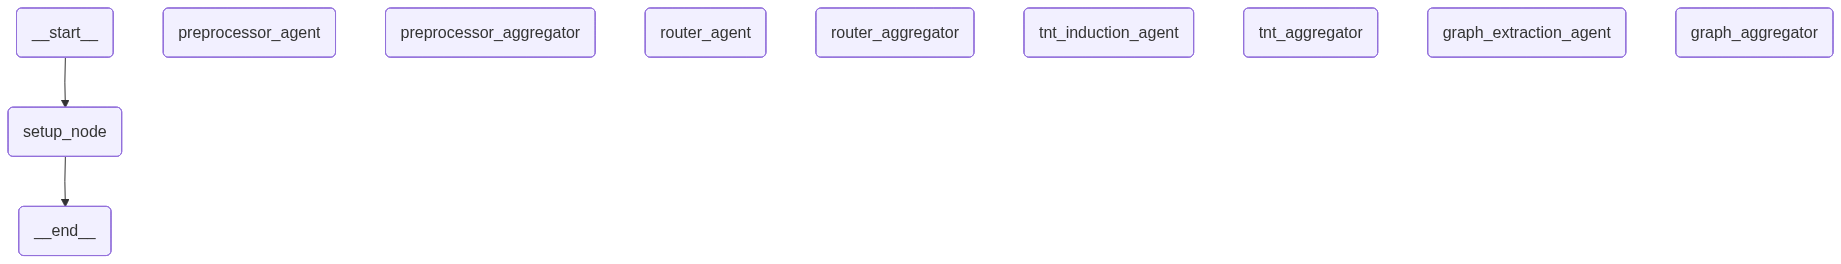

In [37]:
# --- 5. Compile the Workflow ---
logger.info("Compiling End-to-End LangGraph workflow...")
workflow = StateGraph(PipelineState)

# Add Nodes
workflow.add_node("setup_node", setup_data_ingestion_node)
workflow.add_node("preprocessor_agent", preprocessor_agent) # Assumes you have your Pydantic preprocessor defined
workflow.add_node("preprocessor_aggregator", preprocessor_aggregator)
workflow.add_node("router_agent", router_agent) # Assumes you have your Router defined
workflow.add_node("router_aggregator", router_aggregator)
workflow.add_node("tnt_induction_agent", tnt_induction_agent) # Assumes you have your Pydantic TnT defined
workflow.add_node("tnt_aggregator", tnt_aggregator)
workflow.add_node("graph_extraction_agent", graph_extraction_agent) # Assumes your Pydantic Graph Agent is defined
workflow.add_node("graph_aggregator", graph_aggregator)

# Edges: Phase 1
workflow.add_edge(START, "setup_node")
workflow.add_conditional_edges("setup_node", route_to_preprocessors)
workflow.add_edge("preprocessor_agent", "preprocessor_aggregator")

# Edges: Phase 2
workflow.add_conditional_edges("preprocessor_aggregator", dispatch_routers)
workflow.add_edge("router_agent", "router_aggregator")

# Edges: Phase 3
workflow.add_conditional_edges("router_aggregator", dispatch_tnt)
workflow.add_edge("tnt_induction_agent", "tnt_aggregator")

# Edges: Phase 4
workflow.add_conditional_edges("tnt_aggregator", dispatch_graph_extraction)
workflow.add_edge("graph_extraction_agent", "graph_aggregator")

workflow.add_edge("graph_aggregator", END)

dynamic_pipeline = workflow.compile()
logger.info("Pipeline compiled successfully!")
display(Image(dynamic_pipeline.get_graph().draw_mermaid_png()))

In [38]:

# Define the query dynamically at runtime
my_filter_query = {
    "message_count": {"$gt": 30},
    "transcript": {"$regex": "nganang|concierge|tanu", "$options": "i"}
}

# The graph handles the data ingestion, fan-out, preprocessing, and fan-in automatically
final_state = dynamic_pipeline.invoke({
    "mongo_query": my_filter_query,
    "mongo_projection": {"transcript": 1,"thread_id": 1, "_id": 1} # Ensure you fetch _id to use as thread_id
})

print(f"Successfully normalized {len(final_state['normalized_summaries'])} threads!")

Starting setup_data_ingestion_node.
Executing MongoDB fetch with query: {'message_count': {'$gt': 30}, 'transcript': {'$regex': 'nganang|concierge|tanu', '$options': 'i'}}


2026-02-23 00:00:56.717 | INFO     | src.infrastructure.mongo.service:__init__:23 - Successfully connected to MongoDB collection: 'threads'
2026-02-23 00:00:56.761 | INFO     | src.infrastructure.mongo.service:find_many:59 - Retrieved 3 documents from threads


Successfully loaded and mapped 3 threads.
Routing 3 threads to parallel preprocessor agents.
Agent started processing thread_id: 412335439_51510
Agent started processing thread_id: 412335439_66036
Agent started processing thread_id: 412335439_178163
Using Bedrock Converse API to generate response
Using Bedrock Converse API to generate response
Using Bedrock Converse API to generate response
Successfully normalized thread_id: 412335439_66036
Successfully normalized thread_id: 412335439_178163
Successfully normalized thread_id: 412335439_51510
Fan-In Complete: 3 summaries normalized.
Anchoring 3 summaries to L1 Seeds.
Using Bedrock Converse API to generate response
Using Bedrock Converse API to generate response
Using Bedrock Converse API to generate response
Fan-In Complete: 3 threads anchored.
Dispatching TnT-LLM induction across 2 L1 domains.
Using Bedrock Converse API to generate response
Using Bedrock Converse API to generate response
Successfully induced taxonomy for ROOT B
Success

In [34]:
final_state.keys()

dict_keys(['mongo_query', 'mongo_projection', 'raw_threads', 'normalized_summaries', 'failed_threads', 'anchored_threads', 'taxonomy_tree', 'extracted_graphs'])

In [35]:
final_state['extracted_graphs']

[]